# Playing with concepts

In S05 we have seen a lot of concepts in regard of text representation, naive bayes statatistics in NLP, classification, and more. This activity pretends that you play around with the concepts and python code, explore libraries, make experiments, and in general check theory with practice and with reality. To do that, you can use any tool you want including LLMs. Just try to have some findings after your experimentation process for most concepts we have seen. 

### TF-IDF y Naive Bayes for text clasification

In [3]:
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [4]:
# Cargar dataset de noticias
data = fetch_20newsgroups(subset='all', categories=['rec.sport.baseball', 'sci.space'])
texts, labels = data.data, data.target

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)

# Convertir textos a vectores TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Entrenar el clasificador Naive Bayes
clf = MultinomialNB()
clf.fit(X_train_tfidf, y_train)

# Evaluar el modelo
y_pred = clf.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       186
           1       1.00      1.00      1.00       211

    accuracy                           1.00       397
   macro avg       1.00      1.00      1.00       397
weighted avg       1.00      1.00      1.00       397



### Similarity between documents using TF-IDF

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

Forma de la matriz TF-IDF: (4, 11)
Matriz de similitud de coseno:
[[1.         0.         0.25632484 0.        ]
 [0.         1.         0.25632484 0.        ]
 [0.25632484 0.25632484 1.         0.        ]
 [0.         0.         0.         1.        ]]


[nltk_data] Downloading package stopwords to /home/santi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


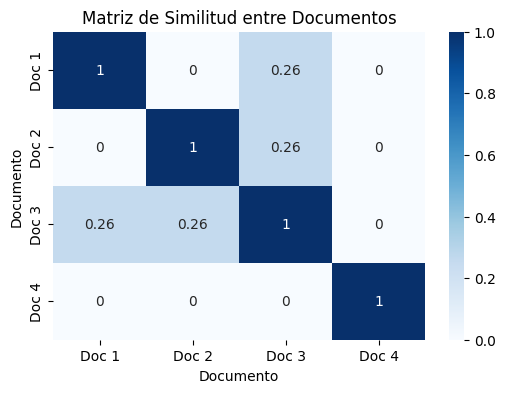

In [ ]:
# Lista de documentos de ejemplo
docs = [
    "El gato se sienta en el tejado.",
    "El perro corre en el parque.",
    "El gato y el perro son amigos.",
    "La inteligencia artificial revoluciona la tecnología."
]

# Obtener la lista de stopwords en español
stop_words_spanish = stopwords.words('spanish')

# Crear el vectorizador TF-IDF utilizando las stopwords en español
vectorizer = TfidfVectorizer(stop_words=stop_words_spanish)
tfidf_matrix = vectorizer.fit_transform(docs)
print("Forma de la matriz TF-IDF:", tfidf_matrix.shape)

# Calcular la similitud de coseno entre documentos
similitudes = cosine_similarity(tfidf_matrix)
print("Matriz de similitud de coseno:")
print(similitudes)

# Visualizar la matriz de similitud con un heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(similitudes, annot=True, cmap='Blues',
            xticklabels=[f'Doc {i+1}' for i in range(len(docs))],
            yticklabels=[f'Doc {i+1}' for i in range(len(docs))])
plt.xlabel("Documento")
plt.ylabel("Documento")
plt.title("Matriz de Similitud entre Documentos")
plt.show()




### Language detection

In [ ]:
from langdetect import detect
import langid

In [ ]:
def detect_language(text):
    # Detección con langdetect
    lang_langdetect = detect(text)

    # Detección con langid
    lang_langid, confidence = langid.classify(text)

    return {
        "langdetect": lang_langdetect,
        "langid": lang_langid,
        "confidence": confidence
    }

# Ejemplo de uso
text1 = "Bonjour tout le monde, j'espère que vous allez bien."
text2 = "Hola a todos, espero que estén bien."

print("Detección de idioma (texto 1):", detect_language(text1))
print("Detección de idioma (texto 2):", detect_language(text2))


Detección de idioma (texto 1): {'langdetect': 'fr', 'langid': 'fr', 'confidence': -212.91563892364502}
Detección de idioma (texto 2): {'langdetect': 'es', 'langid': 'es', 'confidence': -221.1740460395813}


### Sumarize texts

In [15]:
import nltk
import networkx as nx
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

In [ ]:
# Descargar datos de NLTK si no están disponibles
nltk.download('punkt')
nltk.download('stopwords')

def text_rank_summary(text, num_sentences=3):
    # Tokenizar en oraciones
    sentences = sent_tokenize(text)

    # Remover palabras vacías (stopwords)
    stop_words = set(stopwords.words("english"))
    
    # Vectorización TF-IDF para representar cada oración numéricamente
    vectorizer = TfidfVectorizer(stop_words="english")
    sentence_vectors = vectorizer.fit_transform(sentences)

    # Calcular similitud del coseno entre oraciones
    similarity_matrix = np.dot(sentence_vectors, sentence_vectors.T).toarray()

    # Construcción del grafo
    graph = nx.from_numpy_array(similarity_matrix)

    # Aplicar el algoritmo de TextRank
    scores = nx.pagerank(graph)

    # Ordenar oraciones según su puntaje de importancia
    ranked_sentences = sorted(((scores[i], s) for i, s in enumerate(sentences)), reverse=True)

    # Seleccionar las N mejores oraciones para el resumen
    summary = " ".join([ranked_sentences[i][1] for i in range(min(num_sentences, len(sentences)))])
    return summary

# Ejemplo de uso
text = """Artificial intelligence (AI) is intelligence demonstrated by machines, 
as opposed to the natural intelligence displayed by animals and humans. 
Leading AI textbooks define the field as the study of intelligent agents: 
any system that perceives its environment and takes actions that maximize its chance of achieving its goals. 
Some popular applications of AI include natural language processing, robotics, and machine learning."""

summary = text_rank_summary(text, num_sentences=2)
print("Resumen generado:\n", summary)


Resumen generado:
 Some popular applications of AI include natural language processing, robotics, and machine learning. Artificial intelligence (AI) is intelligence demonstrated by machines, 
as opposed to the natural intelligence displayed by animals and humans.


[nltk_data] Downloading package punkt to /home/santi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/santi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Spell checker

In [18]:
from spellchecker import SpellChecker

def spell_check_pyspellchecker(text):
    spell = SpellChecker()

    # Tokenizar el texto en palabras
    words = text.split()
    
    # Identificar palabras mal escritas
    misspelled = spell.unknown(words)

    corrections = {}
    for word in misspelled:
        corrections[word] = spell.correction(word)

    return corrections

# Ejemplo de uso
text = "Ths is a smple text with some mispelled words."
corrections = spell_check_pyspellchecker(text)
print("Correcciones:", corrections)


Correcciones: {'mispelled': 'misspelled', 'smple': 'simple', 'words.': 'words', 'ths': 'the'}
